In [1]:
import os

train_raw = r"dataset-verse19training\rawdata"
case_dirs = sorted(os.listdir(train_raw))
print(f"Anzahl Fälle: {len(case_dirs)}")
print(case_dirs[:5])

# In einen Fall reinschauen
first_case = os.path.join(train_raw, case_dirs[0])
print(os.listdir(first_case))

Anzahl Fälle: 67
['sub-verse004', 'sub-verse005', 'sub-verse006', 'sub-verse007', 'sub-verse008']
['sub-verse004_ct.json', 'sub-verse004_ct.nii.gz']


In [2]:
import nibabel as nib

ct_path = os.path.join(first_case, "sub-verse004_ct.nii.gz")
img = nib.load(ct_path)
print("type(img):", type(img))
print("Shape:", img.shape)
print("Spacing (Voxelgröße mm):", img.header.get_zooms())
print("Orientierung:", nib.aff2axcodes(img.affine))
print("Datentyp:", img.get_data_dtype())

type(img): <class 'nibabel.nifti1.Nifti1Image'>
Shape: (161, 338, 61)
Spacing (Voxelgröße mm): (np.float32(1.0), np.float32(1.0), np.float32(2.000296))
Orientierung: ('P', 'I', 'R')
Datentyp: float32


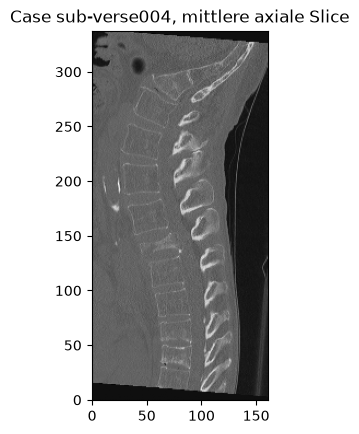

In [3]:
import matplotlib.pyplot as plt

data = img.get_fdata()
mid_slice = data.shape[2] // 2
plt.imshow(data[:, :, mid_slice].T, cmap="gray", origin="lower")
plt.title(f"Case {case_dirs[0]}, mittlere axiale Slice")
plt.show()

In [4]:
import numpy as np
from skimage import measure
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib.pyplot as plt

# Grobes Cropping auf die Körpermitte (Achsen ggf. anpassen, je nach Orientierung deines Volumens)
z_center = data.shape[2] // 2
z_range = 60  # Anzahl Slices um die Mitte herum
cropped = data[:, :, max(0, z_center - z_range):z_center + z_range]

import plotly.graph_objects as go
from skimage import measure

step = 2
volume = cropped[::step, ::step, ::step]
threshold = 300  # nach Schritt 1 ggf. anpassen

verts, faces, normals, values = measure.marching_cubes(volume, level=threshold)

fig = go.Figure(data=[
    go.Mesh3d(
        x=verts[:, 0], y=verts[:, 1], z=verts[:, 2],
        i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
        color="lightgray",
        lighting=dict(ambient=0.4, diffuse=0.8, specular=0.3, roughness=0.5),
        lightposition=dict(x=100, y=200, z=300),
    )
])
fig.update_layout(scene=dict(aspectmode="data"), title="3D-Knochenoberfläche")
fig.show()


In [5]:
import pandas as pd

meta = pd.read_csv("Totalsegmentator_dataset\\meta.csv", sep=";")
print(meta.shape)
meta.head()

(102, 11)


,image_id,age,gender,institute,study_type,split,manufacturer,scanner_model,kvp,pathology,pathology_location
0,s1366,51,NaN,E,ct polytrauma,train,siemens,sensation 64,120,unclear,unclear
1,s0310,23,f,E,ct thorax-neck,train,siemens,somatom definition flash,100,no_pathology,no_location
2,s0250,68,m,E,ct neck-thorax-abdomen-pelvis,train,siemens,somatom definition flash,100,no_pathology,no_location
3,s0223,67,f,E,ct thorax-neck,train,siemens,sensation 64,120,no_pathology,no_location
4,s0011,45,m,B,ct neck-thorax-abdomen-pelvis,train,siemens,emotion 16,130,tumor,"thorax,abdomen,pelvis"


In [6]:
# Wertebereiche der spannenden Spalten
print(meta["split"].value_counts())
print(meta["pathology_location"].value_counts())
print(meta["manufacturer"].value_counts())

split
train    98
val       4
Name: count, dtype: int64
pathology_location
no_location              32
thorax                   24
abdomen                  13
extremity                 6
throat                    5
thorax,abdomen            5
abdomen,pelvis            4
unclear                   3
thorax,abdomen,bones      3
pelvis                    2
bones                     2
thorax,abdomen,pelvis     1
abdomen,bones             1
throat,thorax             1
Name: count, dtype: int64
manufacturer
siemens    100
ge           2
Name: count, dtype: int64


In [10]:
import os
import nibabel as nib
import numpy as np

totalseg_root = "Totalsegmentator_dataset"
case_dirs = sorted(os.listdir(totalseg_root))
print(f"Anzahl Fälle: {len(case_dirs)}")

lumbar_labels = ["vertebrae_L1", "vertebrae_L2", "vertebrae_L3", "vertebrae_L4", "vertebrae_L5"]

results = []
for case in case_dirs:
    seg_dir = os.path.join(totalseg_root, case, "segmentations")
    if not os.path.isdir(seg_dir):
        continue
    present = []
    for lvl in lumbar_labels:
        path = os.path.join(seg_dir, f"{lvl}.nii.gz")
        if os.path.exists(path):
            mask = nib.load(path).get_fdata()
            if mask.sum() > 0:
                present.append(lvl)
    results.append({"case": case, "n_lumbar_present": len(present), "present": present})

df_lumbar = pd.DataFrame(results)
print(df_lumbar["n_lumbar_present"].value_counts().sort_index())

Anzahl Fälle: 103
n_lumbar_present
0     7
1     7
2    15
3     2
4     2
5    69
Name: count, dtype: int64


In [11]:
from collections import Counter

missing_counter = Counter()
for row in results:
    missing = set(lumbar_labels) - set([f"vertebrae_{lvl}" if not lvl.startswith("vertebrae_") else lvl for lvl in row["present"]])
    # row["present"] already stores full names like "vertebrae_L1", so simplify:
    missing = set(lumbar_labels) - set(row["present"])
    for lvl in missing:
        missing_counter[lvl] += 1

print(missing_counter)

Counter({'vertebrae_L5': 31, 'vertebrae_L4': 30, 'vertebrae_L3': 29, 'vertebrae_L2': 15, 'vertebrae_L1': 9})


In [17]:
import ast, numpy as np, pandas as pd, nibabel as nib
from pathlib import Path
OUT = Path(r"C:\Users\anmol\Documents\VSCode\application_BMDNow\processed")
inc = pd.read_csv(OUT / "manifest.csv").query("included")
inc["z"] = inc.proc_shape.map(lambda s: ast.literal_eval(s)[2])
print(inc.sort_values("z")[["dataset", "case", "n_lumbar", "proc_shape"]].iloc[[0, 1, 2, -3, -2, -1]])

lo = hi = n = 0
for _, r in inc.sample(30, random_state=0).iterrows():
    d = OUT / r.dataset / r.case
    ct = nib.load(d / "image.nii.gz").get_fdata()
    v = ct[nib.load(d / "label.nii.gz").get_fdata() > 0]
    lo += (v <= 0.001).sum(); hi += (v >= 0.999).sum(); n += v.size
print(f"Wirbelvoxel am Fenster abgeschnitten: unten {lo/n:.1%}, oben {hi/n:.1%}")

      dataset   case  n_lumbar      proc_shape
124  totalseg  s0310         1    (40, 47, 13)
131  totalseg  s0425         1    (44, 48, 15)
163  totalseg  s0914         1    (41, 48, 15)
209  totalseg  s1387         5  (104, 73, 198)
142  totalseg  s0591         5   (79, 74, 310)
215  totalseg  s1397         5   (92, 93, 349)
Wirbelvoxel am Fenster abgeschnitten: unten 0.0%, oben 0.3%


In [18]:
from scipy.ndimage import label as cc
for c in ["s1397", "s0591", "s1387"]:
    lab = nib.load(OUT / "totalseg" / c / "label.nii.gz").get_fdata().astype(int)
    for k in range(1, 6):
        m = lab == k
        if m.any():
            z = np.where(m.any((0, 1)))[0]
            print(c, f"L{k}", "z:", z.min(), z.max(), "Komponenten:", cc(m)[1], "Voxel:", m.sum())

s1397 L1 z: 10 132 Komponenten: 2 Voxel: 7623
s1397 L2 z: 92 120 Komponenten: 1 Voxel: 8010
s1397 L3 z: 78 105 Komponenten: 1 Voxel: 8049
s1397 L4 z: 68 92 Komponenten: 3 Voxel: 8354
s1397 L5 z: 60 338 Komponenten: 2 Voxel: 8016
s0591 L1 z: 66 90 Komponenten: 1 Voxel: 8198
s0591 L2 z: 49 75 Komponenten: 1 Voxel: 8178
s0591 L3 z: 34 60 Komponenten: 3 Voxel: 9699
s0591 L4 z: 22 299 Komponenten: 4 Voxel: 10031
s0591 L5 z: 10 34 Komponenten: 1 Voxel: 9877
s1387 L1 z: 162 187 Komponenten: 1 Voxel: 8807
s1387 L2 z: 10 170 Komponenten: 2 Voxel: 9435
s1387 L3 z: 125 152 Komponenten: 1 Voxel: 10565
s1387 L4 z: 110 135 Komponenten: 2 Voxel: 10563
s1387 L5 z: 94 120 Komponenten: 1 Voxel: 10874


In [19]:
m = pd.read_csv(OUT / "manifest.csv").query("included")
m["z"] = m.proc_shape.map(lambda s: ast.literal_eval(s)[2])
print(m.z.describe(), (m.removed_fragment_vox > 0).groupby(m.dataset).sum(), sep="\n")

count    196.000000
mean      93.301020
std       27.343141
min       13.000000
25%       93.750000
50%      103.000000
75%      110.000000
max      124.000000
Name: z, dtype: float64
dataset
totalseg     0
verse       63
Name: removed_fragment_vox, dtype: int64


196 {'totalseg': 95, 'verse': 101}
Faelle mit entfernten Fragmenten: {'totalseg': 66, 'verse': 63}
Auffaellige Faelle: [('totalseg', 's0573', 'Reihenfolge'), ('totalseg', 's1221', 'Reihenfolge')]


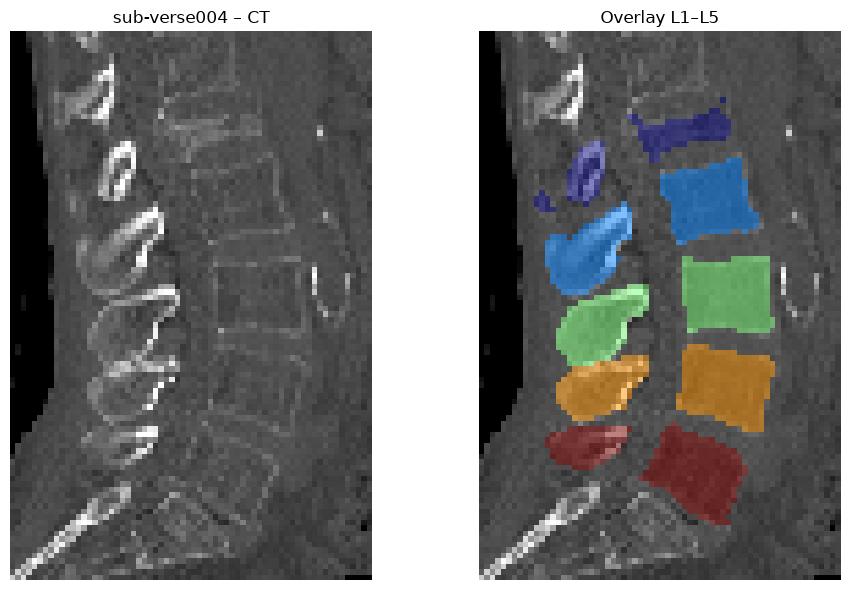

shape=(61, 66, 100)  intensity=[0.00,1.00]  labels=[0 1 2 3 4 5]


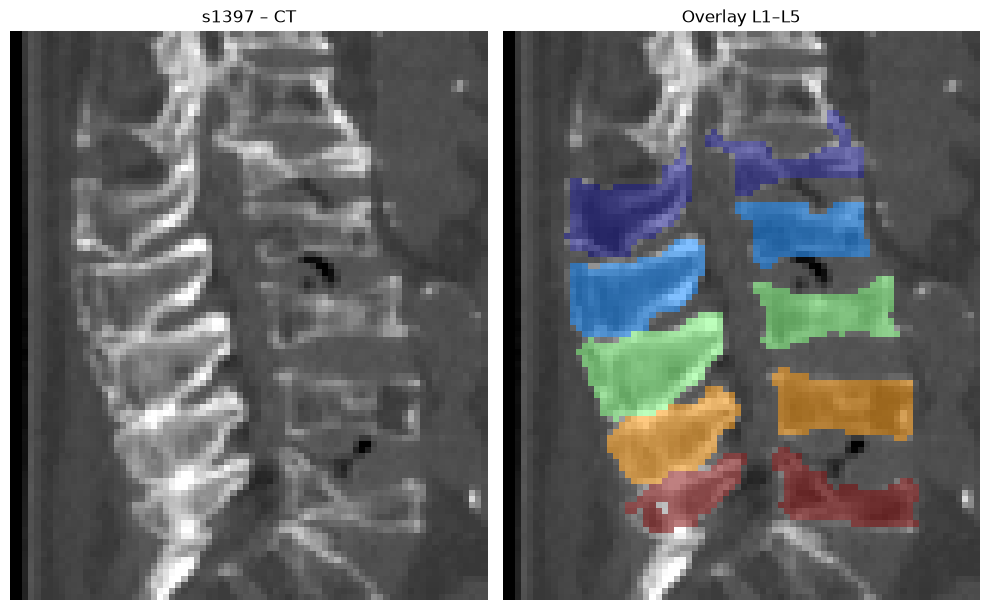

shape=(71, 78, 93)  intensity=[0.00,1.00]  labels=[0 1 2 3 4 5]


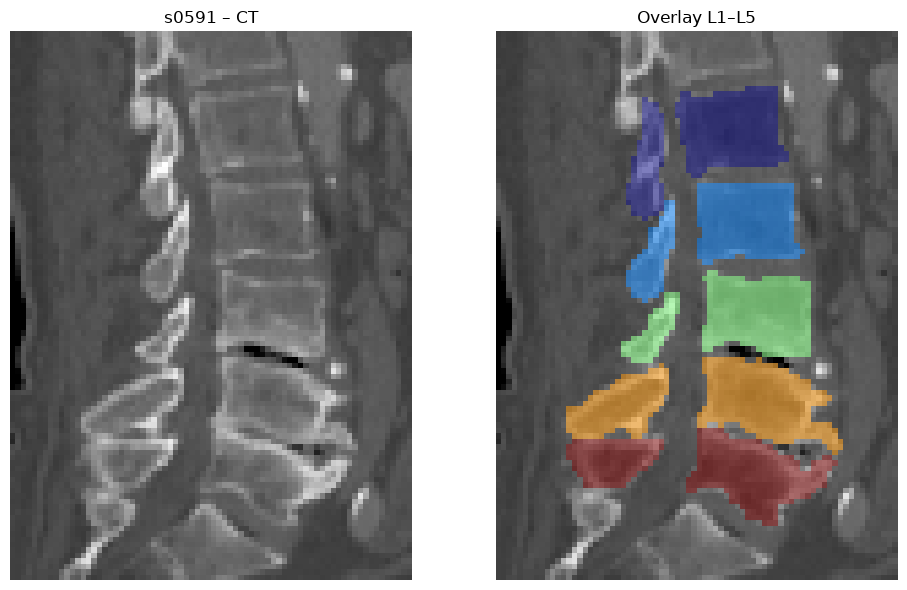

shape=(79, 74, 101)  intensity=[0.00,1.00]  labels=[0 1 2 3 4 5]


In [20]:
import numpy as np, pandas as pd, nibabel as nib
from pathlib import Path
OUT = Path(r"C:\Users\anmol\Documents\VSCode\application_BMDNow\processed")

m = pd.read_csv(OUT / "manifest.csv")
inc = m[m.included]
print(len(inc), inc.groupby("dataset").size().to_dict())
print("Faelle mit entfernten Fragmenten:", inc.groupby("dataset").removed_fragment_vox.apply(lambda s: int((s > 0).sum())).to_dict())

bad = []
for _, r in inc.iterrows():
    d = OUT / r.dataset / r.case
    ci, li = nib.load(d / "image.nii.gz"), nib.load(d / "label.nii.gz")
    ct, lb = ci.get_fdata(), np.asanyarray(li.dataobj)
    zc = {k: np.argwhere(lb == k)[:, 2].mean() for k in range(1, 6) if (lb == k).any()}
    ks = sorted(zc)
    order_ok = all(zc[a] > zc[b] for a, b in zip(ks, ks[1:]))     # L1 oben ... L5 unten
    ok = (ct.shape == lb.shape and np.allclose(ci.affine, li.affine)
          and nib.aff2axcodes(ci.affine) == ("R", "A", "S")
          and not np.isnan(ct).any() and ct.min() >= 0 and ct.max() <= 1
          and set(np.unique(lb).tolist()) <= {0, 1, 2, 3, 4, 5} and order_ok)
    if not ok:
        bad.append((r.dataset, r.case, "Reihenfolge" if not order_ok else "Format"))
print("Auffaellige Faelle:", bad)

from check_overlay import show
for c in ["verse/sub-verse004", "totalseg/s1397", "totalseg/s0591"]:
    show(OUT / c)

s1385 L1 Voxel 7 z 69 69 mean 69.0
s1385 L2 Voxel 3153 z 54 69 mean 65.0
s1385 L3 Voxel 6706 z 41 65 mean 54.0
s1385 L4 Voxel 6660 z 28 52 mean 38.6
s1385 L5 Voxel 7626 z 10 40 mean 25.7


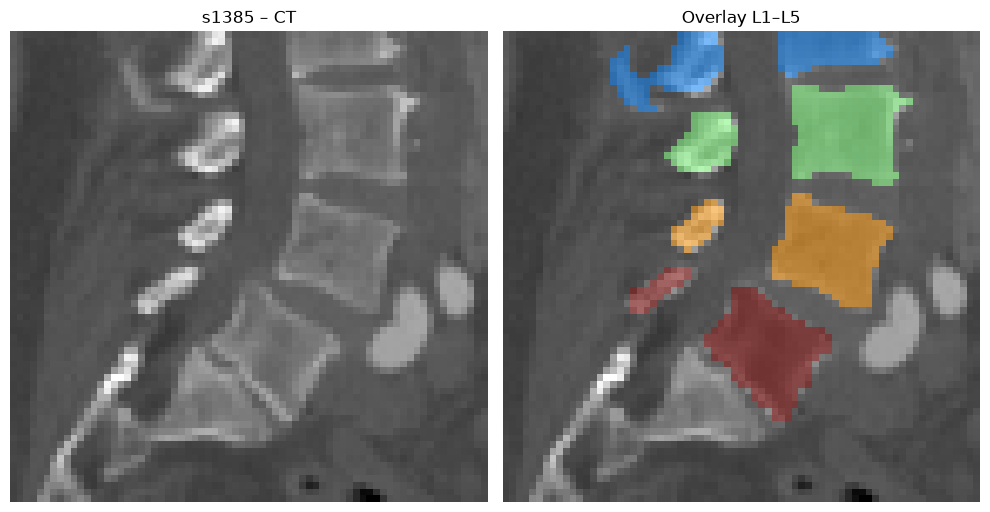

shape=(67, 71, 70)  intensity=[0.00,1.00]  labels=[0 1 2 3 4 5]
s1371 L1 Voxel 9162 z 66 98 mean 82.8
s1371 L2 Voxel 11684 z 50 82 mean 66.8
s1371 L3 Voxel 11304 z 34 66 mean 51.1
s1371 L4 Voxel 10205 z 21 49 mean 36.2
s1371 L5 Voxel 9122 z 10 35 mean 21.9


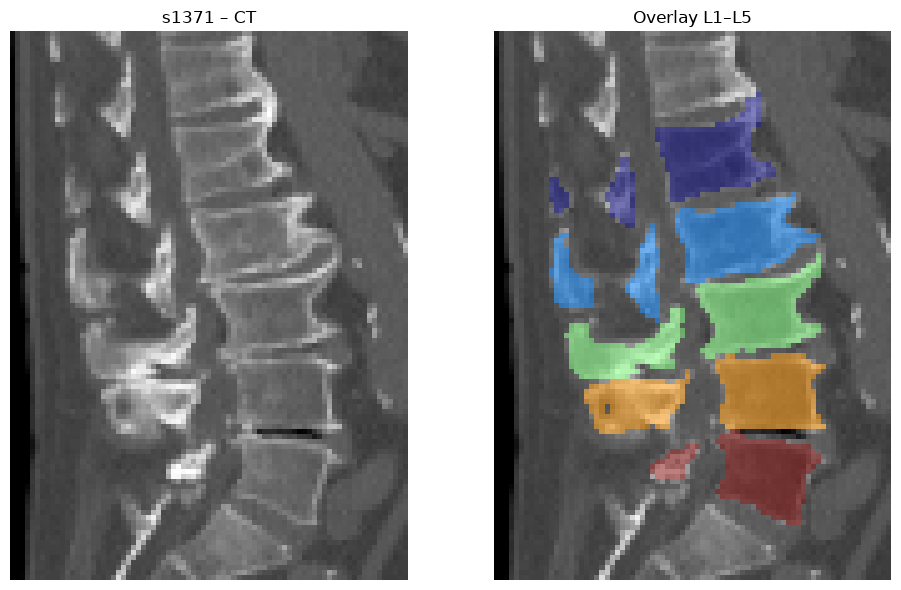

shape=(69, 79, 109)  intensity=[0.00,1.00]  labels=[0 1 2 3 4 5]


In [22]:
from check_overlay import show
for c in ["s1385", "s1371"]:
    lb = np.asanyarray(nib.load(OUT / "totalseg" / c / "label.nii.gz").dataobj)
    for k in range(1, 6):
        z = np.argwhere(lb == k)[:, 2]
        if z.size:
            print(c, f"L{k}", "Voxel", z.size, "z", z.min(), z.max(), "mean", round(z.mean(), 1))
    show(OUT / "totalseg" / c)

Voxel pro Label (bg, L1..L5)  Ground Truth: [582199   6484   7255  15507   7740   7131]
                              Prediction: [581320   6780   7497  15528   7861   7330]


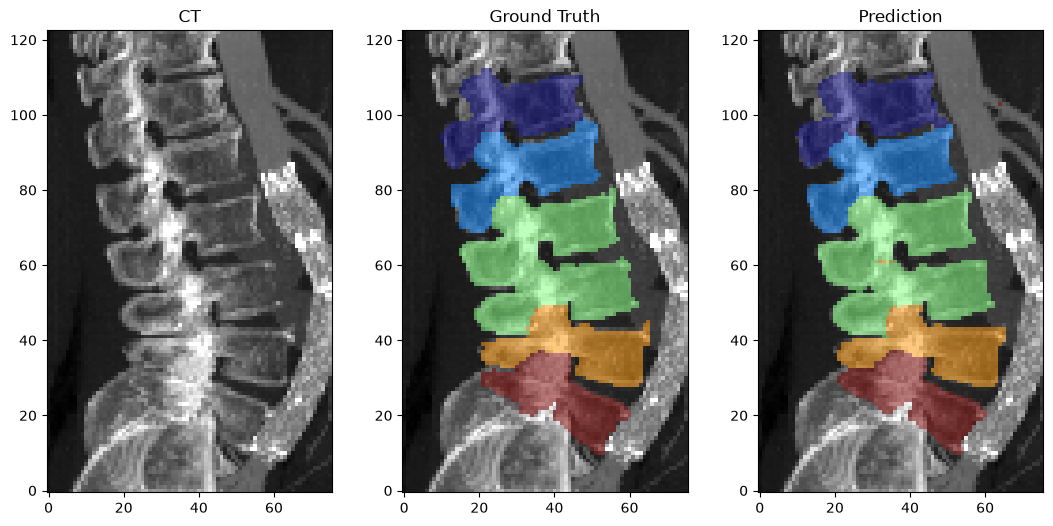

In [36]:
import numpy as np, torch, matplotlib.pyplot as plt
from pathlib import Path
import processed.train as T

ck = torch.load("processed/best.pt", map_location="cpu", weights_only=False)
model = T.build_model(); model.load_state_dict(ck["state_dict"]); model.eval()
img, lab = T.load_case(Path("processed/totalseg/s1405"))
pred = T.predict_volume(model, img, torch.device("cpu"))

print("Voxel pro Label (bg, L1..L5)  Ground Truth:", np.bincount(lab.ravel(), minlength=6))
print("                              Prediction:", np.bincount(pred.ravel(), minlength=6))
fig, ax = plt.subplots(1, 3, figsize=(13, 6))
for a, l, t in zip(ax, (None, lab, pred), ("CT", "Ground Truth", "Prediction")):
    a.imshow(img.max(0).T, cmap="gray", origin="lower")            # Seitenansicht (Kopf oben)
    if l is not None:
        m = l.max(0).T.astype(float)
        a.imshow(np.ma.masked_where(m == 0, m), cmap="jet", vmin=1, vmax=5, alpha=0.5, origin="lower")
    a.set_title(t)
plt.show()